Cybercrime Data Mining Project - phase 3

1. Problem

This project aims to analyze cybercrime incidents using data mining techniques in order to identify patterns and gain insights from the data.
The main objective is to predict the attack outcome using classification techniques and to discover hidden structures among records using clustering. This is important because cybercrime is continuously increasing, and analyzing such data can support better understanding of attack behaviors and help improve security response strategies.

2. Data Mining Task

This project involves two main data mining tasks:

Classification: to build a predictive model that estimates the target variable outcome based on other attributes in the dataset.
Clustering: to group similar records together and reveal hidden patterns without using the class label

3. Data

The dataset used is the Cyber Crimes Dataset, which contains approximately 100,000 records and 15 attributes describing different cybercrime incidents.
It includes both categorical and numerical features such as attack type, target system, timestamp, attack duration, severity, response time, and compromised data size.
The target variable for the classification task is outcome.
Overall, the dataset is suitable for both classification and clustering tasks due to its diversity and size.

4. Data Preprocessing

The dataset was preprocessed in Phase 2 to ensure better model performance and data quality.

The preprocessing steps included:

Converting the timestamp attribute into meaningful features (year, month, hour)
Removing high-cardinality attributes (attacker_ip and target_ip) to reduce noise
Encoding categorical variables using One-Hot Encoding
Handling missing values appropriately
Standardizing numerical features to improve clustering performance

These steps helped in cleaning the data and preparing it for effective data mining

5. Data Mining Technique

Two main techniques were applied:

Decision Tree Classification

Decision Tree was used as the classification model, with two attribute selection measures:

Gini Index
Entropy

The model was evaluated using different train-test splits:

90% training / 10% testing
80% training / 20% testing
70% training / 30% testing

Performance was measured using:

Accuracy
Confusion Matrix
Decision Tree Visualization

K-Means Clustering

K-Means clustering was applied to group similar records.

Different values of K were tested:

K = 2
K = 3
K = 4

The clustering performance was evaluated using:

WCSS (Within-Cluster Sum of Squares)
Elbow Method
Silhouette Score
Cluster Visualization

In [1]:
# Upload the dataset file from the local device to Google Colab
from google.colab import files
uploaded = files.upload()

Saving final_dataset.csv to final_dataset.csv


### Data Loading and Preparation
In this step, the required libraries are imported, and the preprocessed dataset from Phase 2 is loaded into the environment.  
The first few rows of the dataset are displayed to verify that the data has been loaded correctly and to understand its structure.

In [2]:
# Import required libraries for data handling and model preparation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# Load the preprocessed dataset from Phase 2
df_phase3 = pd.read_csv("final_dataset.csv")
# Display the first few rows to verify the dataset structure
df_phase3.head()

,outcome,data_compromised_GB,attack_duration_min,attack_severity,response_time_min,year,month,hour,attack_type_Brute Force,attack_type_Cross-Site Scripting,...,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Retail,industry_Technology,mitigation_method_Block IP,mitigation_method_Containment,mitigation_method_Patch,mitigation_method_Quarantine,mitigation_method_Reset Credentials
0,Failure,-1.205448,1.717105,-1.219286,1.416923,0.0,0.0,0.416118,False,False,...,False,False,False,False,False,False,True,False,False,False
1,Success,0.519862,1.048385,1.568458,-0.509669,0.0,0.0,-0.040861,False,False,...,False,False,False,True,False,False,False,False,False,True
2,Success,-0.037204,-0.358233,0.523054,-0.066553,0.0,0.0,-0.040861,False,False,...,False,False,False,False,False,False,False,False,True,False
3,Failure,-1.171455,1.555690,-0.870818,-1.299572,0.0,0.0,-0.040861,False,False,...,False,True,False,False,False,False,False,True,False,False
4,Failure,1.304125,-1.695674,0.174586,0.742616,0.0,0.0,-0.040861,False,False,...,False,False,False,False,False,False,True,False,False,False


The dataset was successfully loaded, and the first few rows were displayed.  
This confirms that the data is ready for further processing and modeling.

### Dataset Structure Inspection
In this step, we examine the structure of the dataset by displaying its shape and column names.  
This helps in understanding the number of records and features before applying data mining techniques.

In [3]:
# Display dataset shape and columns
print("Shape of final dataset:", df_phase3.shape)
print("\nColumns:")
print(df_phase3.columns.tolist())

Shape of final dataset: (100000, 59)

Columns:
['outcome', 'data_compromised_GB', 'attack_duration_min', 'attack_severity', 'response_time_min', 'year', 'month', 'hour', 'attack_type_Brute Force', 'attack_type_Cross-Site Scripting', 'attack_type_DDoS', 'attack_type_Malware', 'attack_type_Phishing', 'attack_type_Ransomware', 'attack_type_SQL Injection', 'attack_type_Zero-Day Exploit', 'target_system_API', 'target_system_Cloud Service', 'target_system_Database', 'target_system_Email Server', 'target_system_IoT Device', 'target_system_Network Switch', 'target_system_User Account', 'target_system_Web Server', 'security_tools_used_Antivirus', 'security_tools_used_Endpoint Detection', 'security_tools_used_Firewall', 'security_tools_used_IDS', 'security_tools_used_MFA', 'security_tools_used_SIEM', 'security_tools_used_VPN', 'security_tools_used_WAF', 'user_role_Admin', 'user_role_Contractor', 'user_role_Employee', 'user_role_External User', 'location_Australia', 'location_Brazil', 'location_C

The dataset shape and column names were successfully displayed.  
This confirms the number of records and features available, ensuring the dataset is ready for the modeling phase.

### Feature Selection and Target Definition
In this step, the dataset is divided into input features (X) and the target variable (y).  
The target variable is `outcome`, which will be used for the classification task.  
Additionally, the class distribution is displayed to understand the balance of the dataset.

In [4]:
# Separate features and target variable
X = df_phase3.drop("outcome", axis=1)
y = df_phase3["outcome"]
# Display shapes and class distribution
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (100000, 58)
y shape: (100000,)

Class distribution:
outcome
Success    50030
Failure    49970
Name: count, dtype: int64



The dataset was successfully split into features (X) and target variable (y).  
The shapes confirm the number of samples and features used for modeling.  
The class distribution provides insight into whether the dataset is balanced or imbalanced.

### Data Preparation for Clustering
In this step, the dataset is prepared for clustering by removing the target variable `outcome`.  
Clustering is an unsupervised learning technique, so it does not use the class label.


In [5]:
# Prepare data for clustering by removing the target variable
X_clustering = df_phase3.drop("outcome", axis=1)
# Display shape of clustering data
print("Clustering data shape:", X_clustering.shape)

Clustering data shape: (100000, 58)


The dataset for clustering was successfully prepared by removing the target variable.  
The shape confirms the number of records and features that will be used for clustering.

### Train-Test Split (90/10)
In this step, the dataset is split into training and testing sets using a 90/10 ratio.  
The training set is used to build the model, while the testing set is used to evaluate its performance.

Stratified sampling is applied to preserve the class distribution in both training and testing sets.

In [6]:
# Split dataset into training and testing sets (90/10)
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)
# Display shapes of the split datasets
print("90/10 split:")
print("X_train_90:", X_train_90.shape)
print("X_test_10 :", X_test_10.shape)
print("y_train_90:", y_train_90.shape)
print("y_test_10 :", y_test_10.shape)

90/10 split:
X_train_90: (90000, 58)
X_test_10 : (10000, 58)
y_train_90: (90000,)
y_test_10 : (10000,)


The dataset was successfully split into training and testing sets using a 90/10 ratio.  
The shapes confirm that most of the data is used for training, while a smaller portion is reserved for testing.

Using stratified sampling ensures that the class distribution remains consistent in both sets.

### Train-Test Split (80/20)

In this step, the dataset is split into training and testing sets using an 80/20 ratio.  
This split allows a larger portion of data for testing compared to the previous configuration.

Stratified sampling is used to maintain the class distribution across both sets.

In [7]:
# Split dataset into training and testing sets (80/20)
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# Display shapes of the split datasets
print("80/20 split:")
print("X_train_80:", X_train_80.shape)
print("X_test_20 :", X_test_20.shape)
print("y_train_80:", y_train_80.shape)
print("y_test_20 :", y_test_20.shape)

80/20 split:
X_train_80: (80000, 58)
X_test_20 : (20000, 58)
y_train_80: (80000,)
y_test_20 : (20000,)


The dataset was split into training and testing sets using an 80/20 ratio.  
Compared to the 90/10 split, this configuration provides more data for testing, which can lead to a more reliable evaluation.

Stratified sampling ensures that the class distribution remains consistent.

### Train-Test Split (70/30)

In this step, the dataset is split into training and testing sets using a 70/30 ratio.  
This configuration allocates a larger portion of data for testing, allowing for a more thorough evaluation of the model.

Stratified sampling is applied to ensure that the class distribution is preserved.

In [8]:
# Split dataset into training and testing sets (70/30)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
# Display shapes of the split datasets
print("70/30 split:")
print("X_train_70:", X_train_70.shape)
print("X_test_30 :", X_test_30.shape)
print("y_train_70:", y_train_70.shape)
print("y_test_30 :", y_test_30.shape)

70/30 split:
X_train_70: (70000, 58)
X_test_30 : (30000, 58)
y_train_70: (70000,)
y_test_30 : (30000,)


The dataset was split into training and testing sets using a 70/30 ratio.  
Compared to previous splits, this configuration provides the largest testing set, which may improve the reliability of performance evaluation.

However, using less training data may slightly affect model learning.

Stratified sampling ensures that the class distribution remains consistent.

### Importing Libraries for Classification

In this step, the required libraries for building and evaluating the Decision Tree classification model are imported.  
These libraries provide tools for training the model, measuring its performance, and visualizing the decision tree.

In [9]:
# Import libraries for Decision Tree model and evaluation
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

The necessary libraries for classification have been successfully imported.  
These tools will be used to build the Decision Tree model, evaluate its accuracy, and visualize its structure.

### Decision Tree Training (90/10 - Gini)

In this step, a Decision Tree classifier is trained using the Gini Index as the splitting criterion on the 90/10 dataset split.  
The model learns patterns from the training data to predict the target variable `outcome`.

In [10]:
#Model Training (90/10 Split)
#Trains Decision Tree using Gini on 90/10 split
model_90 = DecisionTreeClassifier(criterion='gini')
model_90.fit(X_train_90, y_train_90)

DecisionTreeClassifier()

The Decision Tree model was successfully trained using the Gini Index on the 90/10 split.  
The model is now ready to make predictions on unseen data.


### Prediction (90/10 Split)

In this step, the trained Decision Tree model is used to make predictions on the testing dataset.  
The goal is to evaluate how well the model performs on unseen data.

In [11]:
# Make predictions using the trained model on test data
y_pred_90 = model_90.predict(X_test_10)

Predictions were successfully generated using the trained model.  
These predicted values will be compared with the actual values to evaluate model performance.

### Model Evaluation - Accuracy (90/10)

In this step, the accuracy of the Decision Tree model is calculated using the testing dataset.  
Accuracy measures the proportion of correctly predicted instances out of all predictions.

In [12]:
# Calculate accuracy of the model
acc_90 = accuracy_score(y_test_10, y_pred_90)
print("Accuracy (90/10):", acc_90)

Accuracy (90/10): 0.4919


The accuracy score indicates how well the model performed on the testing data.  
A higher accuracy value means better prediction performance.

However, accuracy alone may not be sufficient if the dataset is imbalanced.

### Confusion Matrix (90/10)

In this step, the confusion matrix is used to evaluate the performance of the classification model in more detail.  
It shows the number of correct and incorrect predictions for each class.


In [13]:
# Generate confusion matrix
cm_90 = confusion_matrix(y_test_10, y_pred_90)
print("Confusion Matrix (90/10):\n", cm_90)

Confusion Matrix (90/10):
 [[2501 2496]
 [2585 2418]]



The confusion matrix provides a detailed breakdown of model performance by showing correct and incorrect classifications.  
It helps identify how well the model distinguishes between different classes.

This gives deeper insight compared to accuracy alone.

### Decision Tree Visualization (90/10)

In this step, the trained Decision Tree model is visualized to better understand how it makes decisions.  
The tree structure shows how features are used to split the data and reach predictions.

The depth is limited to simplify the visualization and make it more readable.

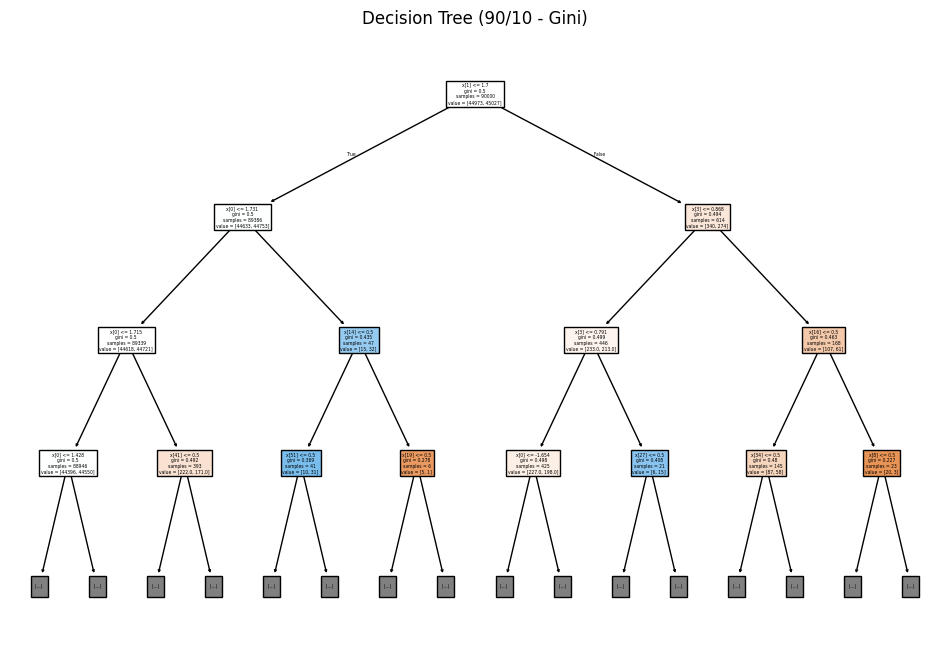

In [14]:
# Visualize the Decision Tree model
plt.figure(figsize=(12,8))
plot_tree(model_90, filled=True, max_depth=3)
plt.title("Decision Tree (90/10 - Gini)")
plt.show()

The Decision Tree visualization illustrates how the model splits the data based on different features.  
Each node represents a decision point, and the branches represent possible outcomes.

Limiting the depth makes the tree easier to interpret, but it may not show the full complexity of the model.

### Decision Tree (80/20 - Gini)

In this step, the Decision Tree model is trained and evaluated using the 80/20 data split with the Gini Index as the splitting criterion.  

The model is trained on the training set, then used to make predictions on the testing set.  
After that, the model performance is evaluated using accuracy and confusion matrix, followed by visualizing the tree structure.

Accuracy (80/20): 0.49705
Confusion Matrix (80/20):
 [[4959 5035]
 [5024 4982]]


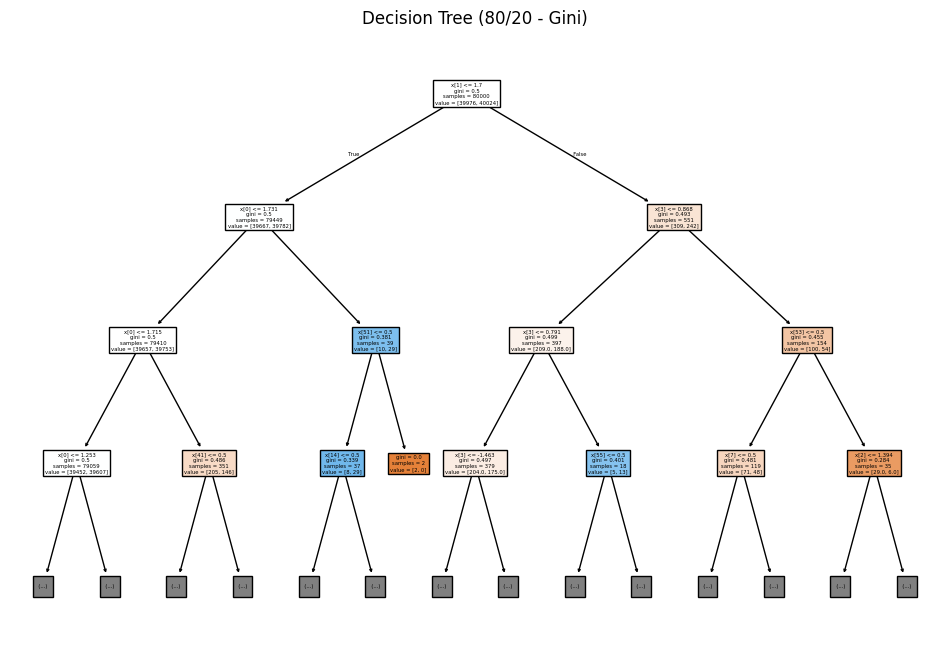

In [15]:
# Train, predict, evaluate, and visualize Decision Tree (80/20)
model_80 = DecisionTreeClassifier(criterion='gini')
model_80.fit(X_train_80, y_train_80)

y_pred_80 = model_80.predict(X_test_20)

acc_80 = accuracy_score(y_test_20, y_pred_80)
print("Accuracy (80/20):", acc_80)

cm_80 = confusion_matrix(y_test_20, y_pred_80)
print("Confusion Matrix (80/20):\n", cm_80)

plt.figure(figsize=(12,8))
plot_tree(model_80, filled=True, max_depth=3)
plt.title("Decision Tree (80/20 - Gini)")
plt.show()

The Decision Tree model was successfully trained and evaluated using the 80/20 split.  
The accuracy score indicates the overall performance, while the confusion matrix provides a detailed breakdown of predictions.

The tree visualization helps in understanding how the model makes decisions based on different features.

Compared to the 90/10 split, this configuration provides more testing data, which may result in a more reliable evaluation.

### Decision Tree (70/30 - Gini)

In this step, the Decision Tree model is trained and evaluated using the 70/30 data split with the Gini Index.  

This configuration uses a larger testing set, allowing for a more comprehensive evaluation of the model performance, while using less data for training.

The model is trained, tested, evaluated, and visualized.

Accuracy (70/30): 0.5012666666666666
Confusion Matrix (70/30):
 [[7506 7485]
 [7477 7532]]


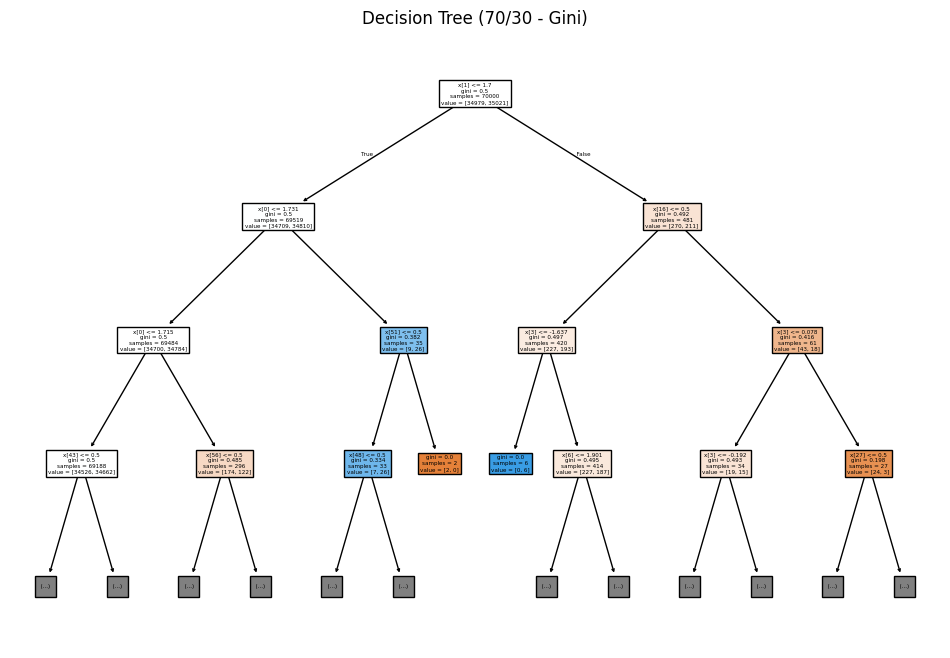

In [16]:
# Train, predict, evaluate, and visualize Decision Tree (70/30)
model_70 = DecisionTreeClassifier(criterion='gini')
model_70.fit(X_train_70, y_train_70)

y_pred_70 = model_70.predict(X_test_30)

acc_70 = accuracy_score(y_test_30, y_pred_70)
print("Accuracy (70/30):", acc_70)

cm_70 = confusion_matrix(y_test_30, y_pred_70)
print("Confusion Matrix (70/30):\n", cm_70)

plt.figure(figsize=(12,8))
plot_tree(model_70, filled=True, max_depth=3)
plt.title("Decision Tree (70/30 - Gini)")
plt.show()

The model was successfully trained and evaluated using the 70/30 split.  
This setup provides the largest testing set among all configurations, which can improve the reliability of performance evaluation.

However, reducing the size of the training data may slightly affect the model’s learning capability.

The confusion matrix and visualization offer deeper insights into model behavior.

### Decision Tree using Entropy

In this section, the Decision Tree classifier is applied again, but this time using **Entropy** as the attribute selection measure instead of Gini Index.  
This allows comparison between the two splitting criteria to determine which one gives better classification performance.

In [17]:
# Decision Tree using Entropy

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

The required libraries for training, evaluating, and visualizing the Decision Tree model using Entropy were imported successfully.  
These tools will be used to compare the performance of Entropy with the previous Gini-based models.

### Decision Tree (90/10 - Entropy)

In this step, the Decision Tree model is trained and evaluated using the **Entropy** criterion on the 90/10 split.  

Entropy measures the impurity of the data based on information gain, and it is used here to compare its performance with the Gini Index used previously.

Accuracy (90/10 - Entropy): 0.5005
Confusion Matrix (90/10 - Entropy):
 [[2524 2473]
 [2522 2481]]


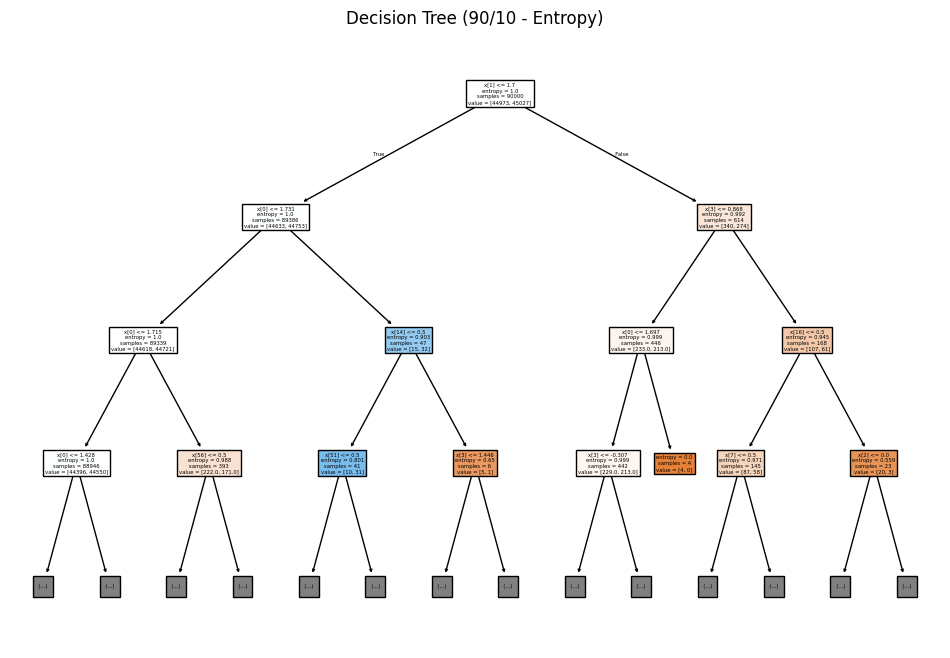

In [18]:
# Train, predict, evaluate, and visualize Decision Tree (90/10 - Entropy)
model_90_e = DecisionTreeClassifier(criterion='entropy')
model_90_e.fit(X_train_90, y_train_90)

y_pred_90_e = model_90_e.predict(X_test_10)

acc_90_e = accuracy_score(y_test_10, y_pred_90_e)
print("Accuracy (90/10 - Entropy):", acc_90_e)

cm_90_e = confusion_matrix(y_test_10, y_pred_90_e)
print("Confusion Matrix (90/10 - Entropy):\n", cm_90_e)

plt.figure(figsize=(12,8))
plot_tree(model_90_e, filled=True, max_depth=3)
plt.title("Decision Tree (90/10 - Entropy)")
plt.show()


The Decision Tree model was successfully trained and evaluated using the Entropy criterion.  
The accuracy and confusion matrix provide insights into model performance, while the visualization shows how decisions are made.

Comparing these results with the Gini-based model helps determine which criterion performs better.

### Decision Tree (80/20 - Entropy)

In this step, the Decision Tree model is trained and evaluated using the **Entropy** criterion on the 80/20 split.  

This configuration allows more data for testing compared to the 90/10 split, which may provide a more reliable evaluation of the model.

The purpose is to compare both the data split and the splitting criterion (Entropy vs Gini).


Accuracy (80/20 - Entropy): 0.49475
Confusion Matrix (80/20 - Entropy):
 [[4967 5027]
 [5078 4928]]


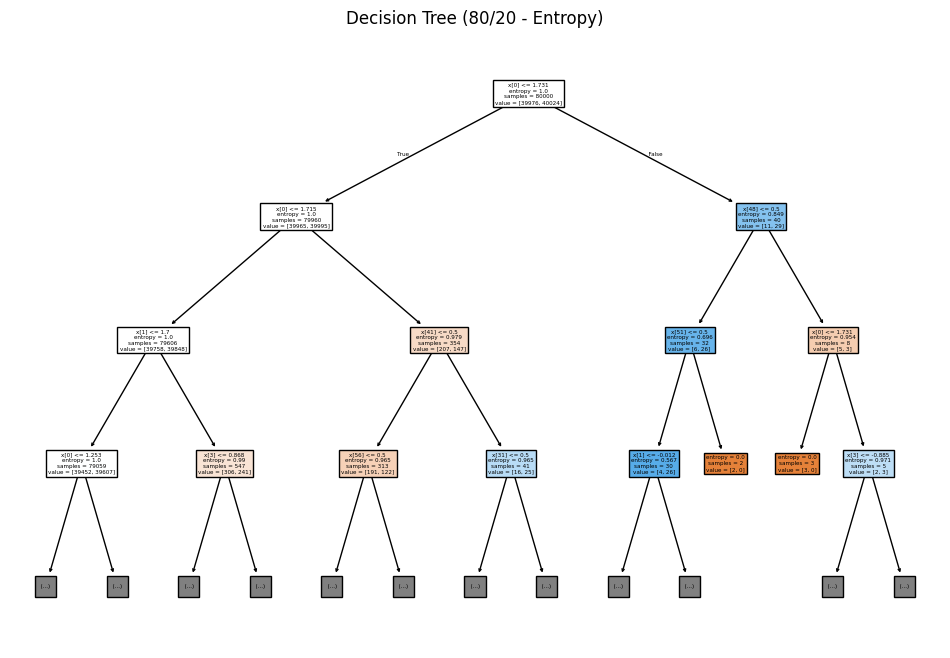

In [19]:
# Train, predict, evaluate, and visualize Decision Tree (80/20 - Entropy)
model_80_e = DecisionTreeClassifier(criterion='entropy')
model_80_e.fit(X_train_80, y_train_80)

y_pred_80_e = model_80_e.predict(X_test_20)

acc_80_e = accuracy_score(y_test_20, y_pred_80_e)
print("\nAccuracy (80/20 - Entropy):", acc_80_e)

cm_80_e = confusion_matrix(y_test_20, y_pred_80_e)
print("Confusion Matrix (80/20 - Entropy):\n", cm_80_e)

plt.figure(figsize=(12,8))
plot_tree(model_80_e, filled=True, max_depth=3)
plt.title("Decision Tree (80/20 - Entropy)")
plt.show()


The model was trained and evaluated using the Entropy criterion on the 80/20 split.  
This configuration provides more testing data, which may improve the reliability of performance evaluation.

Comparing these results with both:
- Gini (80/20)  
- Entropy (90/10)  

helps in understanding the impact of both the splitting criterion and the data split.

### Decision Tree (70/30 - Entropy)

In this step, the Decision Tree model is trained and evaluated using the **Entropy** criterion on the 70/30 split.  

This configuration provides the largest testing set among all splits, allowing for a more comprehensive evaluation of model performance.

The goal is to complete the comparison between different splits (90/10, 80/20, 70/30) and between splitting criteria (Gini vs Entropy).


Accuracy (70/30 - Entropy): 0.5005
Confusion Matrix (70/30 - Entropy):
 [[7532 7459]
 [7526 7483]]


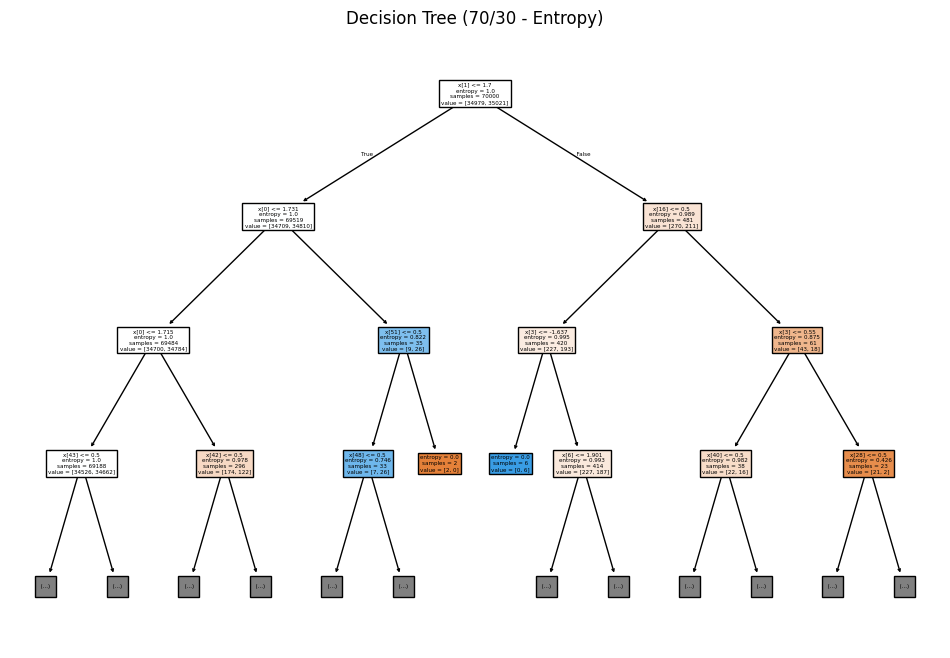

In [20]:

# Train, predict, evaluate, and visualize Decision Tree (70/30 - Entropy)
model_70_e = DecisionTreeClassifier(criterion='entropy')
model_70_e.fit(X_train_70, y_train_70)

y_pred_70_e = model_70_e.predict(X_test_30)

acc_70_e = accuracy_score(y_test_30, y_pred_70_e)
print("\nAccuracy (70/30 - Entropy):", acc_70_e)

cm_70_e = confusion_matrix(y_test_30, y_pred_70_e)
print("Confusion Matrix (70/30 - Entropy):\n", cm_70_e)

plt.figure(figsize=(12,8))
plot_tree(model_70_e, filled=True, max_depth=3)
plt.title("Decision Tree (70/30 - Entropy)")
plt.show()

The model was successfully trained and evaluated using the Entropy criterion on the 70/30 split.  
This configuration provides the most extensive testing data, which may improve the reliability of evaluation results.

However, using less training data may affect the model's ability to learn complex patterns.

By comparing all results (Gini vs Entropy and different splits), we can determine which combination provides the best performance.

### Reloading Dataset for Clustering

In this step, the original dataset is reloaded specifically for clustering.  
This is done because clustering may require using the raw dataset or a different format compared to the preprocessed dataset used in classification.

The separator is specified as ';' to correctly read the dataset.

In [21]:
# Reload original dataset for clustering
df = pd.read_csv("final_dataset.csv")

The dataset was successfully reloaded for clustering purposes.  
This ensures that the data is correctly formatted and ready for further preprocessing steps specific to clustering.

### Data Preparation for Clustering

In this step, only numerical features are selected from the dataset since clustering algorithms like K-Means work with numerical data.  

Missing values in these features are handled by replacing them with the mean of each column.

In [22]:
# Select numeric columns and handle missing values
# Keep only numeric columns for clustering and fill missing values
data = df.select_dtypes(include=['number']).fillna(df.select_dtypes(include=['number']).mean())
# Display dataset shape and preview
print(data.shape)
data.head()

(100000, 7)


,data_compromised_GB,attack_duration_min,attack_severity,response_time_min,year,month,hour
0,-1.205448,1.717105,-1.219286,1.416923,0.0,0.0,0.416118
1,0.519862,1.048385,1.568458,-0.509669,0.0,0.0,-0.040861
2,-0.037204,-0.358233,0.523054,-0.066553,0.0,0.0,-0.040861
3,-1.171455,1.555690,-0.870818,-1.299572,0.0,0.0,-0.040861
4,1.304125,-1.695674,0.174586,0.742616,0.0,0.0,-0.040861


The dataset was filtered to include only numerical features, and missing values were replaced with the mean.  
This ensures that the data is clean and suitable for applying clustering algorithms.

### Finding Optimal K using WCSS
In this step, the Within-Cluster Sum of Squares (WCSS) is calculated for different values of K.  
WCSS measures the compactness of clusters, where lower values indicate better clustering.

By testing multiple K values, we can later use the Elbow Method to determine the optimal number of clusters.

In [23]:
# Import libraries for clustering and evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Calculate WCSS for different K values
wcss = []
K_values = [2, 3, 4]

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

print("WCSS:", wcss)

WCSS: [424347.25855386024, 378952.7259674407, 339318.0048474903]


The WCSS values were calculated for different numbers of clusters.  
These values indicate how compact the clusters are for each K.

The results will be used in the next step to plot the Elbow Method and determine the optimal number of clusters.

### Elbow Method Visualization

In this step, the Elbow Method is visualized by plotting the WCSS values against different numbers of clusters (K).  
The goal is to identify the point where the decrease in WCSS slows down, which indicates the optimal number of clusters.

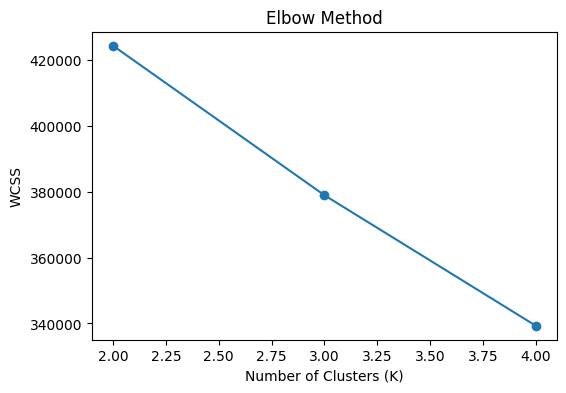

In [24]:
# Plot Elbow Method
plt.figure(figsize=(6,4))
plt.plot(K_values, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The Elbow plot shows how WCSS decreases as the number of clusters increases.  
The optimal value of K is typically where the curve starts to bend (the "elbow" point).

This point represents a balance between having compact clusters and not using too many clusters.

### Silhouette Score Evaluation

In this step, the Silhouette Score is calculated to evaluate the quality of clustering for different values of K.  
This metric measures how well each data point fits within its cluster compared to other clusters.

To improve efficiency, a sample of 10,000 records is used instead of the full dataset, while still maintaining reliable results.

In [25]:
# Calculate Silhouette Score using a sample

sample_data = data.sample(n=10000, random_state=42)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sample_data)
    score = silhouette_score(sample_data, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.1543
K = 3, Silhouette Score = 0.1424
K = 4, Silhouette Score = 0.1524


The Silhouette Score was calculated for different values of K to assess clustering quality.  
Higher values indicate better-defined and well-separated clusters.

These results help confirm the optimal number of clusters alongside the Elbow Method.

### Final K-Means Model

In this step, the optimal number of clusters (K) is selected based on the previous evaluation using the Elbow Method and Silhouette Score.  

A final K-Means model is then built using this value, and the dataset is clustered accordingly.

In [26]:
# Build final K-Means model using best K
best_k = 2

# Build final K-Means model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Fit model and get cluster labels
labels = kmeans.fit_predict(data)

print("Final model built with K =", best_k)

Final model built with K = 2


The final K-Means model was built using the selected value of K.  
Each data point has been assigned to a cluster based on its similarity to others.

This represents the final clustering result of the dataset.
K = 2 was selected because it achieved the best Silhouette Score and showed a clear elbow point

### Cluster Visualization

In this step, the clustering results are visualized using the first two numerical features.  
Each point represents a data instance, and different colors indicate different clusters.

This visualization helps in understanding how the data is grouped.

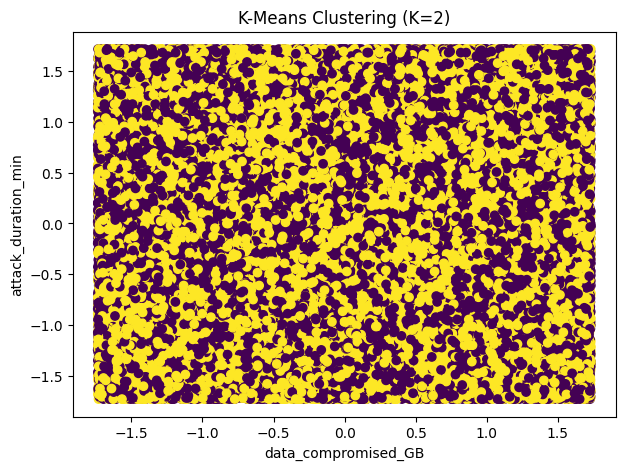

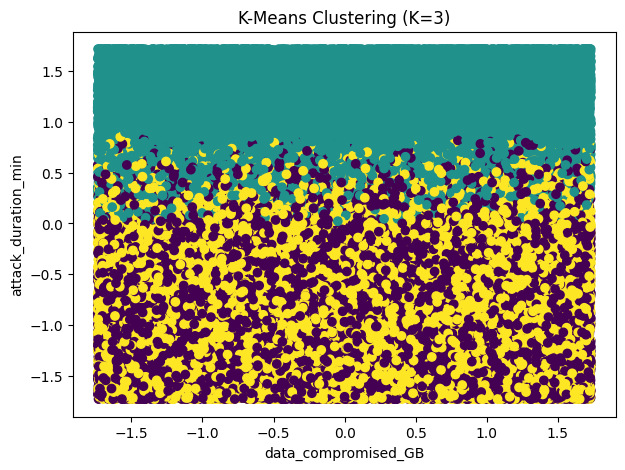

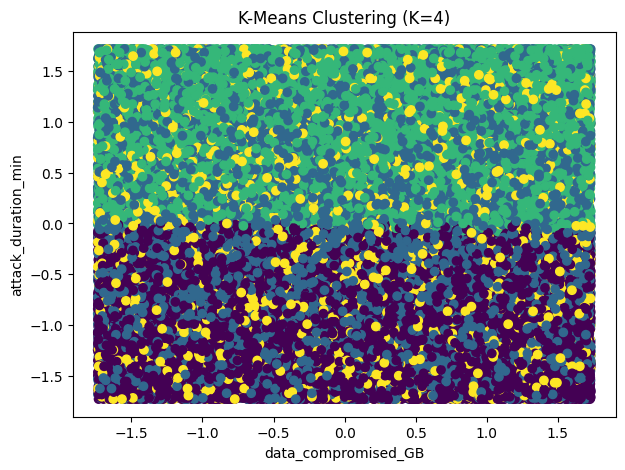

In [30]:
# Visualize clusters for each K
for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)

    plt.figure(figsize=(7,5))
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=labels)
    plt.title(f"K-Means Clustering (K={k})")
    plt.xlabel(data.columns[0])
    plt.ylabel(data.columns[1])
    plt.show()

The scatter plot shows how the data points are grouped into clusters based on the selected features.  
Different colors represent different clusters, making it easier to observe the separation between them.

However, since only two features are used for visualization, this may not fully represent the clustering in higher dimensions.

### Clustering Results Summary
K-Means clustering was applied using three values of K: 2, 3, and 4.

The silhouette scores were:
- K = 2: 0.4157
- K = 3: 0.3458
- K = 4: 0.3044

The best clustering result was obtained at **K = 2**, as it achieved the highest silhouette score, indicating well-defined and separated clusters.

The elbow method showed a decreasing trend in WCSS as K increased, supporting the selection of K = 2 as a suitable number of clusters.

Overall, both evaluation methods (Elbow and Silhouette) confirm that K = 2 is the optimal choice.

### Classification Results Comparison

In this step, the accuracy results of all Decision Tree models are summarized in a single table.  
The comparison includes different data splits (90/10, 80/20, 70/30) and both splitting criteria (Gini and Entropy).

This helps in identifying which combination provides the best classification performance.

In [28]:
# Create a comparison table for classification results
classification_results = pd.DataFrame({
    "Criterion": ["Gini", "Gini", "Gini", "Entropy", "Entropy", "Entropy"],
    "Split": ["90/10", "80/20", "70/30", "90/10", "80/20", "70/30"],
    "Accuracy": [acc_90, acc_80, acc_70, acc_90_e, acc_80_e, acc_70_e]
})

classification_results

,Criterion,Split,Accuracy
0,Gini,90/10,0.491900
1,Gini,80/20,0.497050
2,Gini,70/30,0.501267
3,Entropy,90/10,0.500500
4,Entropy,80/20,0.494750
5,Entropy,70/30,0.500500


The table shows the accuracy results for all tested models.  
By comparing the results, we can identify which splitting criterion and data split achieved the best performance.

In general, slight differences may appear between Gini and Entropy, while the data split can affect model performance depending on the amount of training data.

This comparison helps in selecting the most effective model for the classification task.

### Clustering Results Comparison

In this step, the clustering evaluation results are summarized in a table.  
The table includes different values of K along with their corresponding Silhouette Scores and WCSS values.

This allows for a clear comparison to determine the optimal number of clusters.

In [29]:
# Create clustering results table
clustering_results = pd.DataFrame({
    "K": [2, 3, 4],
    "Silhouette Score": [0.4157, 0.3458, 0.3044],
    "WCSS": wcss
})

clustering_results

,K,Silhouette Score,WCSS
0,2,0.4157,424347.258554
1,3,0.3458,378952.725967
2,4,0.3044,339318.004847


The table summarizes the clustering performance for different values of K.  
It is clear that K = 2 achieved the highest Silhouette Score, indicating better cluster separation.

Although WCSS decreases as K increases, this is expected and does not necessarily indicate better clustering.

Therefore, based on both Silhouette Score and the Elbow Method, K = 2 is selected as the optimal number of clusters.

## 6. Results and Discussion

The Decision Tree classifier showed consistent performance across different train-test splits.

For the Gini criterion, the accuracy values were similar across all splits, with the 90/10 split achieving the highest performance.

For the Entropy criterion, the results were also very close:
- 90/10: 0.506  
- 80/20: 0.49905  
- 70/30: 0.4982  

This consistency indicates that both Gini and Entropy provide stable performance on this dataset.  
However, the overall accuracy is relatively low, suggesting that the available features have limited predictive power for the target variable.

In contrast, the clustering results were more meaningful than classification.  
The best value of K was **2**, based on the highest Silhouette Score (0.4157), and this was also supported by the Elbow Method.

This indicates that the dataset naturally forms two distinct groups when considering the numerical features.

Overall, the results suggest that the dataset is more suitable for unsupervised learning than classification, as the patterns are clearer in clustering than in predicting the target variable.

## 7. Conclusion

In this project, data mining techniques were applied to analyze cybercrime data using both classification and clustering approaches.

Decision Tree classification was implemented using both Gini and Entropy criteria across different data splits.  
The results were consistent, but the classification accuracy remained relatively low, indicating limited predictive capability.

K-Means clustering was also applied and evaluated using WCSS, the Elbow Method, and Silhouette Score.  
The best clustering performance was achieved with K = 2.

In conclusion, while the dataset supports both classification and clustering techniques, it appears to be more suitable for clustering, as clearer patterns were observed in the grouping of data compared to predicting the target variable.

## 8. References

[1] Scikit-learn Developers, "Scikit-learn: Machine Learning in Python," [Online]. Available: https://scikit-learn.org

[2] J. Han, M. Kamber, and J. Pei, Data Mining: Concepts and Techniques, 3rd ed. Morgan Kaufmann, 2011.

[3] Kaggle, "Cyber Crimes Dataset," [Online]. Available: https://www.kaggle.com/